## NLP Analysis on Reddit Repair-Oriented Discourse

### Scraping Reddit Data

In [ ]:
import praw
import re
import pandas as pd

In [277]:
reddit = praw.Reddit(
        client_id = '1RSoiiidEQHVgW7YVwlubA',
        client_secret = 'zJpONyQaL_GzTTGM9Ye-U0Mg9MI8qA',
        user_agent = 'script:my_nlp_app:v1.0 (Evie-F-2025)'
    )

/Users/macbookair/Data Science/myenv/.venv/lib/python3.13/site-packages/update_checker.py:160: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  diff = datetime.utcnow() - the_datetime
Version 7.8.1 of praw is outdated. Version 7.8.2 was released 2 days ago.


In [4]:
# building corpus of repair-oriented community discourse

repair_subreddits = ['BuyItForLife', 'fixit', 'ZeroWaste', 'DIY', 'Anticonsumption', 'frugal', 'repair', 'upcycling', 'righttorepair']
data = []

import prawcore

for sub_name in repair_subreddits:
    subreddit = reddit.subreddit(sub_name)
    try:
        for post in subreddit.top(limit=10):  # top = filters for the highest upvoted posts within a specific time range. This is best for finding high-quality content or popular discussions.
            post_data = {
                'Type': 'post',
                'Title': post.title,
                'Time Stamp': post.created_utc,
                'Score': post.score,
                'Id': post.id,
                'Url': post.url,
                'Num Comments': post.num_comments,
                'Post Text': post.selftext
            }
            data.append(post_data)

            if post.num_comments > 0:
                post.comments.replace_more(limit=0)
                for comment in post.comments.list():
                    comment_data = {
                        'Type': 'comment',
                        'Post Id': post.id,
                        'Comment Id': comment.id,
                        'Comment Text': comment.body,
                        'Score': comment.score,
                        'Time Stamp': comment.created_utc
                    }
                    data.append(comment_data)
    except prawcore.exceptions.Forbidden:
        print("forbidden subreddit:", sub_name)
        continue

repair_subreddit_data = pd.DataFrame(data)
repair_subreddit_data.head()

forbidden subreddit: BuyItForLife
forbidden subreddit: fixit
forbidden subreddit: ZeroWaste
forbidden subreddit: DIY
forbidden subreddit: Anticonsumption
forbidden subreddit: frugal
forbidden subreddit: repair
forbidden subreddit: upcycling
forbidden subreddit: righttorepair


""


In [57]:
# filtering by key words derived from interview themes

keywords = [
    # Material
    'repair', 'fix', 'broken', 'replacement', 'spare parts', 
    'throw away', 'waste', 'equipment', 'time', 'cost', 'legislation'
    
    # Competence
    'skill', 'learn', 'teach', 'confident', 'intimidated',
    'tutorial', 'ifixit', 'manual', 'diagnose', 'expert', 
    
    # Consuming subject
    'upgrade', 'worth repairing', 'not worth', 'cheaper to replace',
    'planned obsolescence', 'designed to break', 'convenient', 'dispose',
    
    # Repair identity and resistance
    'refuse to throw', 'right to repair', 'resist', 'anticonsumption',
    'keep forever', 'Capitalism', 'ethical', 'obligated'
    
    # Object relations
    'sentimental', 'memory', 'grandmother', 'grandfather', 'salvage'
    'heirloom', 'inherited', 'attachment', 'still works',
    
    # Community
    'repair cafe', 'restart project', 'tool library', 'swap'
    'community repair', 'skill share', 'volunteer' 'share'
]

# create a regex string: "python|web scraping|data analysis"
keyword_pattern = '|'.join(keywords)

# filter titles 
filtered_repair_df = repair_subreddit_data[repair_subreddit_data['Comment Text'].str.contains(keyword_pattern, case=False, na=False) 
                             | repair_subreddit_data['Post Text'].str.contains(keyword_pattern, case=False, na=False)]

# combine post text and comment text into one column for analysis
filtered_repair_df['combined_text'] = filtered_repair_df['Post Text'].fillna('') + ' ' + filtered_repair_df['Comment Text'].fillna('')

filtered_repair_df.head()

,Type,Title,Time Stamp,Score,Id,Url,Num Comments,Post Text,Post Id,Comment Id,Comment Text,combined_text
1,comment,NaN,1.546286e+09,1026,NaN,NaN,NaN,NaN,ab7l6x,ecyrm3p,What model do you have?\n\nTomTom GPS devices ...,What model do you have?\n\nTomTom GPS devices...
2,comment,NaN,1.546268e+09,3976,NaN,NaN,NaN,NaN,ab7l6x,ecy3g71,"Meanwhile, my 12 year old little Garmin nuvi 2...","Meanwhile, my 12 year old little Garmin nuvi ..."
5,comment,NaN,1.546267e+09,4881,NaN,NaN,NaN,NaN,ab7l6x,ecy2l7i,"For the lifetime they determine, not for how l...","For the lifetime they determine, not for how ..."
6,comment,NaN,1.546271e+09,1439,NaN,NaN,NaN,NaN,ab7l6x,ecy70hw,Contact your state's attorney general's office...,Contact your state's attorney general's offic...
7,comment,NaN,1.546281e+09,64,NaN,NaN,NaN,NaN,ab7l6x,ecykem6,"In Massachusetts, lifetime on a contract means...","In Massachusetts, lifetime on a contract mean..."


### Data Cleaning Pipeline

In [278]:
# Importing Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import contractions
import emoji
nlp = spacy.load('en_core_web_sm')

In [ ]:
# Preprocessing Pipeline

NEGATIONS = {'not', "n't", 'never', 'no', 'without', 'cannot',
             "can't", "won't", "didn't", "doesn't", "don't"} # keep negations to preserve context meaning

KEEP_POS = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV', 'PART'} # keep only parts of speech that carry meaning (removes filler words and noise)

stop_words = set(stopwords.words('english')) - NEGATIONS # remove stop words but keep negations

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return '' # return empty string for non-string or empty input
    
    # cleaning
    text = contractions.fix(text) # Expand contractions
    text = emoji.replace_emoji(text, replace='') # Remove emojis
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<[^>]+>|&\w+;', '', text) # Remove HTML tags 
    text = re.sub(r'\*+|\^+|^>+', '', text, flags=re.MULTILINE) # Remove Reddit formatting
    text = re.sub(r'r/\w+|u/\w+|\[deleted\]|\[removed\]', '', text) # Remove Reddit-specific tags
    text = re.sub(r'[^\w\s\'-]', ' ', text) # Remove punctuation except for negation-related characters
    text = re.sub(r'\s+', ' ', text).strip().lower() # Deal with whitespace and make lowercase

   # tokenizing, POS tagging, lemmatizing
    doc = nlp(text) 
    lemmas = [] # storing lemmas 
    for token in doc: # iterate through tokens
        is_negation = token.text in NEGATIONS or token.lemma_ in NEGATIONS # checking if token is a negation
        keep = (
            (token.pos_ in KEEP_POS or is_negation)
            and not token.is_punct
            and not token.is_space
            and not token.like_num
            and len(token.text) > 1
        ) # keep criteria
        if keep and (is_negation or token.text not in stop_words):
            lemmas.append(token.text if is_negation else token.lemma_.lower()) # this preserves the original negation word instead of its lemma, while lemmatizing and lowercasing other tokens

    return ' '.join(lemmas) # Return cleaned text

# Apply to combined text column on filtered_repair_df
filtered_repair_df['combined_text'] = (filtered_repair_df['Post Text'].fillna('') + ' ' 
                                + filtered_repair_df['Comment Text'].fillna('') ).str.strip() # Combine and clean whitespace

filtered_repair_df = filtered_repair_df[filtered_repair_df['combined_text'].apply(lambda t: len(t.split()) >= 20)].copy() # Filter out short posts before preprocessing

# Apply preprocessing to combined text and filter out empty results
filtered_repair_df['lemmatised_text'] = filtered_repair_df['combined_text'].apply(preprocess_text)
filtered_repair_df = filtered_repair_df[filtered_repair_df['lemmatised_text'].str.strip().ne('')].copy()
filtered_repair_df.head()

,Type,Title,Time Stamp,Score,Id,Url,Num Comments,Post Text,Post Id,Comment Id,Comment Text,combined_text,lemmatised_text
1,comment,NaN,1.546286e+09,1026,NaN,NaN,NaN,NaN,ab7l6x,ecyrm3p,What model do you have?\n\nTomTom GPS devices ...,What model do you have?\n\nTomTom GPS devices ...,model tomtom gps device pretty shitty lockout ...
2,comment,NaN,1.546268e+09,3976,NaN,NaN,NaN,NaN,ab7l6x,ecy3g71,"Meanwhile, my 12 year old little Garmin nuvi 2...","Meanwhile, my 12 year old little Garmin nuvi 2...",meanwhile year old little garmin nuvi 200w sti...
5,comment,NaN,1.546267e+09,4881,NaN,NaN,NaN,NaN,ab7l6x,ecy2l7i,"For the lifetime they determine, not for how l...","For the lifetime they determine, not for how l...",lifetime determine not long device last lot pe...
6,comment,NaN,1.546271e+09,1439,NaN,NaN,NaN,NaN,ab7l6x,ecy70hw,Contact your state's attorney general's office...,Contact your state's attorney general's office...,contact state 's attorney general 's office le...
7,comment,NaN,1.546281e+09,64,NaN,NaN,NaN,NaN,ab7l6x,ecykem6,"In Massachusetts, lifetime on a contract means...","In Massachusetts, lifetime on a contract means...",massachusetts lifetime contract mean lifetime ...


In [ ]:
# saving as csvs
filtered_repair_df.to_csv('filtered_repair_subreddit_data.csv', index=False)

In [279]:
# upload filtered_repair_df and filtered_general_df csvs as dataframes
filtered_repair_df = pd.read_csv('filtered_repair_subreddit_data.csv')

## TF-IDF 

### Applied to assess theme prevelance in corpus

In [280]:
# Theme dictionaries from thematic analysis of interviews - refined version 2


theme_dictionaries = {

    'system': [
        'obsolescence', 'obsolete', 'planned obsolescence',  
        'intentional', 'deliberate',
        'sealed', 'proprietary', 'glued', 'welded',
        'hidden screw', 'secret screw',                      
        'manufacturer', 'producer', 'corporation',
        'iphone', 'apple', 'samsung', 'dyson',
        'brand name',                                       
        'legislation', 'policy', 'law', 'directive', 'regulation',
        'framework', 'right to repair',                    
        'EU', 'UK', 'parliament',
        'linear economy',                                   
        'throwaway culture',                                
        'disposable', 'single-use', 'fast fashion',        
        'market forces',                                     
        'e-waste', 'electronic waste',                       
        'landfill', 'dump', 'export waste',                 
        'global south', 'Africa',
        'grassroots', 'campaign', 'movement',
        'lobby', 'petition', 'advocacy',
        'pressure on manufacturers',                         
        'systemic', 'structural change', 'reform', 'overhaul',  
        'design flaw', 'designed to fail',                  
        'warranty void', 'warranty',                        
        'refuse to repair',                                
        'uphill battle',                                    
        'against throwaway',                               
        'locked in', 'stuck with',                          
        'inevitable system', 'unavoidable',                  
        # reomoved entirely: 'resist', 'power', 'reckoned', 'dominate', 'economy' - too generic, causing false positives across multiple themes
    ],

    'infrastructure': [
        # Repair space vocabulary — made more specific
        'repair cafe', 'repair cafes',                       
        'repair venue', 'repair workshop',                   
        'restart project', 'iFixit',
        'community repair',                                  
        'volunteer', 'volunteering',
        'goodwill', 'donation', 'grant', 'grants',
        'charity funding',                                   
        'funding', 'underfunded',
        'subsidy', 'subsidised repair',                     
        'inconsistent', 'irregular', 'unreliable',
        'precarious', 'fragile', 'unstable', 'temporary',
        'disappear', 'closing down', 'shut down',          
        # Cost — made specific to repair context
        'cost of repair', 'repair cost',                   
        'affordable repair', 'unaffordable repair',
        'too expensive to repair',
        # Tools and parts — made specific
        'repair tools', 'spare parts', 'spare part',       
        'parts inventory',                                  
        # Signposting — made specific
        'find a repair', 'locate repair', 'signposting',   
        'repair signpost', 'repair awareness',             
        # Added from validation
        'thrift store', 'thrift stores',
        'flea market', 'flea markets',
        'second hand store', 'secondhand',
        'prohibition on repair',                            
        # Access barriers — made specific
        'inaccessible repair', 'hard to find repair',      
        'impossible to fix',                                
        'repair desert',                                   
        # Ecosystem metaphors — made specific
        'repair ecosystem', 'fragile repair',              
        'sustain repair', 'repair infrastructure',         
        'repair nightmare', 'nightmare to find',       
    ],

    'competence': [
        # Core skill vocabulary — made specific to repair
        'repair skill', 'repair skills',                    
        'repair knowledge', 'technical knowledge',
        'learn to repair', 'learning to fix',              
        'teach repair', 'teaching repair',
        'trained to repair', 'educated in repair',     
        'repair practice',                                 
        # Confidence and self-efficacy — made specific
        'confident repairing', 'repair confidence',     
        'able to repair', 'ability to repair',
        'competent repair', 'repair competence',        
        # Fear and anxiety — rmade specific
        'afraid to repair', 'scared to repair',            
        'fear of breaking', 'fear of making it worse',
        'nervous about repairing',                    
        'generation', 'grandparent', 'parent',
        'pass down skill', 'inherited skill',            
        'tradition of repair', 'olden days',
        'grew up repairing', 'grew up fixing',
        'class', 'background', 'privilege',
        'free time to repair',                             
        'type of person', 'not for me', 'not my thing',
        'repair identity',                                
        # Resources — made specific
        'repair tutorial', 'repair manual',                
        'repair guide', 'how to fix', 'how to repair',
        'iFixit', 'repair resource',                       
        # Added from validation
        'easy to repair', 'easy to fix',
        'repairability', 'fixability',
        # Metaphor extensions — made specific
        'skill inheritance', 'inherit repair skill',        
        'skill transfer', 'hand down skill',                
        'gain repair skill', 'develop repair skill',        
        'forget how to repair', 'lost the skill',         
        'natural repairer', 'born to repair',            
        'repair in DNA', 'DNA',
        'second nature to repair',                       
        'repair talent', 'knack for repair',             
        'skill deficit', 'skill gap',                     
        # removed entirely: 'surprised', 'information', 'help', 'expert', 'professional', 'experienced', 'strange', 'alien', 'foreign', - too generic, caught off-topic documents
    ],

    'consumer': [
        # Convenience framing — made specific
        'convenient to replace',                           
        'too much hassle to repair',                        
        'simpler to buy new',                              
        'too busy to repair',                               
        
        'guilt', 'guilty about throwing',
        'bad conscience', 'on my conscience',               
        'know I should repair', 'know better',
        'aware I should fix',                            
        # Replacement vocabulary — made specific
        'buy new', 'buying new', 'buy a new one',
        'latest model', 'latest version',
        'upgrade', 'just replace', 'replace it',
        'purchase a new',                                
        'status symbol', 'social signalling',           
        'label', 'logo', 'impress others',
        'materialistic', 'consumerism', 'overconsumption',
        'stuff', 'possessions',                             
        'throwaway culture',                               
        'short-lived purchase',                            
        # Added from validation
        'replaced it', 'just replaced',
        'wasteful', 'being wasteful',
        'bought myself a new', 'bought a replacement',
        'invest in a new',                                  
        'accumulate', 'accumulating things',
        'collection', 'collecting new',
        # Economic frame — made specific to replacement 
        'not worth repairing', 'not worth fixing',
        'cheaper to replace', 'cheaper to buy',             
        'cost benefit of replacing',
        'spend on new',                                    
        'want the new', 'crave new',
        'desire for new',                                  
        'satisfy with new', 'indulge',
        'appetite for new',                                
        'thrill of new', 'rush of buying',                
        'fleeting satisfaction', 'excitement of new',       
        # Default behaviour — made specific
        'default to buying',                               
        'automatic replacement',                         
        # Social construction — made specific
        'told to buy new', 'conditioned to replace',      
        'programmed to consume',                            
        'scroll', 'browsing amazon', 'instagram shopping',
    ],

    'repair_identity': [
        # Resistance vocabulary — made specific
        'refuse to replace', 'refuse to buy new',          
        'against throwaway culture',                      
        'challenge consumer culture',                      
        'defy planned obsolescence',                       
        'meaning in repair', 'meaningful repair',          
        'purpose of repair', 'sense of purpose',         
        'vocation', 'calling', 'mission to repair',        
        # Ethics — made specific
        'moral obligation to repair',                      
        'duty to repair', 'right thing to repair',         
        'ethical consumption', 'ethical repair',            
        'hope in repair', 'optimism about repair',          
        'proud of fixing', 'pride in repair',               
        'repair is possible', 'possibility of repair',      
        # Making and craft — added from validation
        'labour of repair', 'repair labour',               
        'labor of repair', 'repair labor',
        'sewing', 'sewing machine', 'mending',
        'scraps', 'using scraps', 'making do',
        'crafting', 'handcraft', 'hand repair',
        'inexpensive repair', 'low cost repair',
        'create', 'make', 'craft repair',
        'build', 'construct',                               
        # Contribution — made specific
        'useful repair', 'contribute through repair',       
        'serve community through repair',                   
        'community repair identity',                        
        'repair identity', 'who I am as a repairer',      
        'values around repair', 'repair values',            
        'conviction to repair',                             
        # Metaphor extensions — made specific
        'fight against throwaway',                         
        'battle against obsolescence',
        'tend to objects', 'nurture repair',                
        'care for objects', 'attend to objects',           
        'steward of objects', 'stewardship',
        'restore to working', 'revive object',              
        'bring back to life', 'reclaim object',             
        'salvage from landfill',                            
        'empowered by repair', 'sense of agency',           
        'deliberate choice to repair', 'intentional repair', 
        # removed entirely: 'middle', 'counter', 'push back', 'stand against', 'plant', 'seed', 'bloom', 'flourish' - wrong meanin, too generic
    ],

    'object_relations': [
        'memory', 'memories', 'remember', 'nostalgia', 'nostalgic',
        'sentimental', 'sentimental value',
        'remind me of', 'reminds me',                      
        'grandmother', 'grandma', 'grandfather', 'grandad', 'grandpa',
        'grandparents',                                      
        'grew up with',                                     
        'parent', 'mum', 'mom', 'dad', 'father', 'mother',
        'gift', 'given to me', 'handed down',
        'passed down', 'inherited',
        'heirloom', 'family heirloom',
        'companion', 'faithful companion',                 
        'beloved', 'cherished', 'loved object',            
        'attached to', 'bond with', 'connection to object', 
        # Care vocabulary — refined
        'keep forever', 'hold onto',                      
        'preserve', 'save this object',                    
        'protect', 'treasure',
        'look after it', 'care for it',
        'salvage this', 'salvage object',                 
        'history of object', 'story of this',             
        'life of object', 'years of use',                  
        'alongside me',                                    
        # Added from validation
        'looks good still', 'still looks good',
        'busted', 'completely busted',
        'part ways with', 'parting with it',
        'lifetime of use', 'last a lifetime',
        'longevity', 'long lasting',
        'honour the object', 'honor the object',
        'worth more to me', 'means more to me',
        'broke my heart', 'heartbroken',
        'it broke', 'when it broke',                        
        'grieve for object', 'grief when lost',            
        'let it go', 'hard to let go',                      
        'hope it survives', 'faith in object',              
        'afraid of breaking it', 'scared of damaging',    
        'fear of killing it',                               
        'harm it', 'ruin it', 'destroy it',                
        'make it worse',                                    
        'antique', 'vintage',
        'old faithful', 'well worn',                       
        'retained', 'kept for years',
        # Living being metaphors — made specific 
        'still alive', 'keeping it alive',                 
        'on its last legs', 'dying',
        'loyal object', 'reliable object',                  
        'abandon it', 'abandoning',                         
        'neglect it',                                       
        # Repository metaphors — made specific
        'carries memories', 'holds memories',               
        'preserve memories', 'keep memories safe',         
        # removed entirely: 'lost', 'pain', 'carrying', 'meaningful', 'damage', 'kill', 'hurt', 'die', 'death' reason: caught off-topic documents unrelated to object attachment
    ],

    'community': [
        # Core community vocabulary — made specific
        'repair community', 'repair communities',           
        'collective repair', 'repair collective',          
        'repair group', 'repair groups',
        'shared repair', 'mutual repair',                   
        'neighbour', 'neighbours', 'neighborhood', # includes US spelling
        'neighbourhood repair', 'local repair',             
        # Belonging — made specific
        'repair belonging', 'belong to repair group',     
        'open to all', 'accessible repair',                 
        # Social connection — made specific
        'social repair', 'repair connection',             
        'meet to repair', 'gather to fix',                 
        'learn together repair', 'fix together',           
        'exchange repair skills', 'interact over repair',   
        # Solidarity — made specific
        'repair solidarity', 'repair support',             
        'mutual aid repair', 'volunteer repair',           
        # Alternative framing — made specific
        'alternative to buying new',                        
        'counter to consumerism',                         
        # Added from validation
        'repair cafe', 'repair cafes',
        'restart party', 'restart project',
        'repair event', 'repair session',
        'repair movement', 'repair culture',
        'skill share', 'skill sharing',
        'repair hub', 'repair centre', 'repair center',
        'community workshop',
        'fix-it clinic', 'fixit clinic',
        # Organism metaphors — made specific
        'repair ecosystem growing',                         
        'sustaining repair community',                     
        # Place metaphors — made specific
        'repair space', 'repair place',                   
        'repair centre', 'repair hub',
        # Weaving metaphors — made specific or removed
        'fabric of repair',                                 
        'repair network',                                  
        # Grounding metaphors — made specific
        'roots of repair', 'grounded in repair',           
        'repair flourishing',                            
        # removed entirely: 'together', 'environment', 'sustainable', 'taught', 'learn', 'share', 'happy', 'moved', 'grow', 'sustain', 'place' - all caught off-topic documents, too generic
    ],

}


In [281]:
# Importing TF-IDF packages

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [282]:
# converting lists to strings for vectoriser
theme_strings = {k: ' '.join(v) for k, v in theme_dictionaries.items()}
theme_names = list(theme_strings.keys())
theme_corpus = list(theme_strings.values())

# loading the cleaned text from filtered_repair_df
documents = filtered_repair_df['lemmatised_text'].tolist() # creating list of documents from lemmatised text column
len(documents)

# fitting TF-IDF vectoriser 
vectorizer = TfidfVectorizer(
    max_features=1000,  # Limit to top 1000 features
    min_df=2,          # Only include terms that appear in at least 2 documents
    max_df=0.8,        # Exclude terms that appear in more than 80% of documents
    ngram_range=(1, 2), # Include unigrams and bigrams
    sublinear_tf=True,  # Use sublinear term frequency scaling
)

tfidf_matrix = vectorizer.fit_transform(documents + theme_corpus) # fitting on combined corpus to ensure same feature space for documents and themes
len(vectorizer.vocabulary_)

# separate document vectors and theme vectors
doc_vectors = tfidf_matrix[:len(documents)]
theme_vectors = tfidf_matrix[len(documents):]

# computing cosine similarity between documents and themes
similarity_matrix = cosine_similarity(doc_vectors, theme_vectors) # cosine similarity = dot product of normalized vectors, gives value between 0 and 1 indicating similarity in feature space

# building results df
similarity_df = pd.DataFrame(similarity_matrix, columns=theme_names)

# finding dominant theme per document
similarity_df['dominant_theme'] = similarity_df[theme_names].idxmax(axis=1)

# finding maximum similarity score per document
similarity_df['max_similarity'] = similarity_df[theme_names].max(axis=1)

# flagging low-signal documents — similarity too low to be meaningful
# Threshold of 0.05 is conservative — adjust based on your distribution
similarity_df['low_signal'] = similarity_df['max_similarity'] < 0.05
similarity_df.head(20)

,system,infrastructure,competence,consumer,repair_identity,object_relations,community,dominant_theme,max_similarity,low_signal
0,0.057937,0.000000,0.010656,0.104125,0.059810,0.047777,0.033291,consumer,0.104125,False
1,0.013423,0.000000,0.008281,0.006227,0.000000,0.065565,0.022936,object_relations,0.065565,False
2,0.037868,0.000000,0.023822,0.044913,0.025616,0.083062,0.018136,object_relations,0.083062,False
3,0.000000,0.025818,0.024966,0.008163,0.000000,0.071638,0.000000,object_relations,0.071638,False
4,0.000000,0.000000,0.038145,0.000000,0.029774,0.068876,0.000000,object_relations,0.068876,False
5,0.026664,0.025428,0.032295,0.017115,0.016889,0.000000,0.041831,community,0.041831,True
6,0.000000,0.000000,0.006568,0.050717,0.007943,0.030717,0.000000,consumer,0.050717,False
7,0.000000,0.000000,0.000000,0.000000,0.026271,0.057044,0.000000,object_relations,0.057044,False
8,0.008194,0.032900,0.013898,0.000000,0.000000,0.045414,0.000000,object_relations,0.045414,True
9,0.000000,0.030020,0.000000,0.011934,0.010663,0.024492,0.000000,infrastructure,0.030020,True


In [283]:
# percentage of documents identified as low_signal
low_signal_percentage = similarity_df['low_signal'].value_counts(normalize=True) * 100
print(low_signal_percentage)

low_signal
False    54.989309
True     45.010691
Name: proportion, dtype: float64


In [284]:
# Analysis of results

# dominant theme distribution
print("\nDominant theme distribution:")
theme_dist = (
    similarity_df[~similarity_df['low_signal']]
    ['dominant_theme']
    .value_counts(normalize=True) * 100 # percentage of documents with a dominant theme, excluding low-signal documents
)
print(theme_dist.round(1).to_string()) # rounded to 1dp 

# low-signal documents
print(f"\nLow-signal documents: {similarity_df['low_signal'].sum():,} "
      f"({similarity_df['low_signal'].mean():.1%})") # number and percentage of documents flagged as low-signal

# mean similarity theme distribution
print("\nMean similarity per theme across all documents:")
mean_similarities = similarity_df[theme_names].mean().sort_values(ascending=False) # average similarity score for each theme across all documents, sorted highest to lowest
print(mean_similarities.round(4).to_string()) # rounded to 4dp 

# themes that tend to appear together at high similarity consistently
print("\nTheme co-occurrence — top pairs:")
for i, theme_a in enumerate(theme_names):
    for theme_b in theme_names[i+1:]:
        corr = similarity_df[[theme_a, theme_b]].corr().iloc[0, 1] # correlation between similarity scores for theme_a and theme_b across documents
        if corr > 0.3:  # only report meaningful correlations - moderate positive
            print(f"  {theme_a} + {theme_b}: r={corr:.3f}")

# format results as df
results_df = pd.DataFrame({
    'Theme': theme_dist.index,
    'Percentage of Documents': theme_dist.values,
    'Mean Similarity': mean_similarities[theme_dist.index].values
}).reset_index(drop=True)
results_df.head(20)



Dominant theme distribution:
dominant_theme
object_relations    25.4
consumer            23.6
infrastructure      17.2
system              14.1
competence           6.8
community            6.7
repair_identity      6.2

Low-signal documents: 1,263 (45.0%)

Mean similarity per theme across all documents:
consumer            0.0302
object_relations    0.0288
infrastructure      0.0226
repair_identity     0.0214
competence          0.0203
system              0.0189
community           0.0179

Theme co-occurrence — top pairs:
  system + repair_identity: r=0.323
  infrastructure + competence: r=0.537
  infrastructure + consumer: r=0.345
  infrastructure + repair_identity: r=0.562
  infrastructure + community: r=0.633
  competence + repair_identity: r=0.468
  competence + community: r=0.676
  consumer + repair_identity: r=0.466
  consumer + community: r=0.347
  repair_identity + community: r=0.561


,Theme,Percentage of Documents,Mean Similarity
0,object_relations,25.405055,0.028752
1,consumer,23.590408,0.030209
2,infrastructure,17.174336,0.022562
3,system,14.128321,0.018928
4,competence,6.804925,0.020254
5,community,6.740117,0.017946
6,repair_identity,6.156837,0.021378


In [285]:
# saving v2 distribution for comparison with v1
counts = similarity_df['dominant_theme'].value_counts(normalize=True)
theme_dist_v2 = (counts * 100).round(1)

print("v2 distribution saved:")
print(theme_dist_v2.to_string())

v2 distribution saved:
dominant_theme
object_relations    26.8
consumer            20.8
infrastructure      14.4
system              13.2
competence           9.9
repair_identity      8.0
community            6.9


In [286]:
# saving v1 distribution for comparison with v2
counts = similarity_df['dominant_theme'].value_counts(normalize=True)
theme_dist_v1 = (counts * 100).round(1)

print("v1 distribution saved:")
print(theme_dist_v1.to_string())

v1 distribution saved:
dominant_theme
object_relations    26.8
consumer            20.8
infrastructure      14.4
system              13.2
competence           9.9
repair_identity      8.0
community            6.9


In [287]:
# comparing v1 vs v2 dominant theme distribution:

v1_dist = {
    'consumer': 25.8,
    'competence': 15.4,
    'object_relations': 14.5,
    'infrastructure': 12.6,
    'system': 11.8,
    'repair_identity': 10.8,
    'community': 9.1,
}

v2_dist = {
    'consumer': 26.8,
    'competence': 20.8,
    'object_relations': 14.4,
    'infrastructure': 13.2,
    'system': 9.9,
    'repair_identity': 8.0,
    'community': 6.9,
}

comparison = pd.DataFrame({
    'v1_%': v1_dist,
    'v2_%': v2_dist
}).fillna(0) # filling missing features with 0% 

comparison['change'] = (comparison['v2_%'] - comparison['v1_%']).round(1) # the rise or fall in % from v1 to v2

print("Theme distribution: v1 vs v2")
print(comparison.to_string())

Theme distribution: v1 vs v2
                  v1_%  v2_%  change
consumer          25.8  26.8     1.0
competence        15.4  20.8     5.4
object_relations  14.5  14.4    -0.1
infrastructure    12.6  13.2     0.6
system            11.8   9.9    -1.9
repair_identity   10.8   8.0    -2.8
community          9.1   6.9    -2.2


## TF-IDF Analysis

In [ ]:
# Tables and Visualisations
import matplotlib.patches as mpatches  # for custom legend colour boxes
import seaborn as sns                 

theme_names = ['system', 'infrastructure', 'competence', 'consumer','repair_identity', 'object_relations', 'community']

# defining columns

# dominant theme column contains the theme with the highest cosine similarity for each document - discursive formation most present in that post    
# value counts to see how many documents have each theme as dominant, normalized to get percentages, rounded to 1 decimal place for readability
dominant_pct = (similarity_df['dominant_theme'].value_counts(normalize=True) * 100).round(1)

# mean similarity = average strength of presence (cosine similarity) across the corpus, not just peak presence
mean_sim = similarity_df[theme_names].mean().round(4)

# co-occurence correlation = Pearson correlation value between every pair of themes, based on their similarity scores across documents
# A high positive r means: documents that score high on theme A also tend to score high on theme B — they co-occur in the same posts
# A negative r means: documents high on theme A tend to be low on theme B — they tend not to co-occur
corr = similarity_df[theme_names].corr()

# top_theme = finding strongest co-occurrence for each theme 
def get_top_cooccurrence(theme, corr_matrix, theme_list):
    row = corr_matrix[theme].drop(theme)  # drop self-correlation
    top_theme = row.idxmax() # name of most correlated theme
    top_r = row.max() # correlation value
    return f"{top_theme} (r={top_r:.2f})"

# creating assigned subject positions for each theme
subject_positions = {
    'consumer':'Consuming subject / Guilty disposer',
    'competence':'Structurally frustrated / Skilled self-maker',
    'object_relations':'Relational steward / Guilty disposer',
    'infrastructure':'Structurally frustrated',
    'system':'Political refuser / Structurally frustrated',
    'repair_identity':'Skilled self-maker / Political refuser',
    'community':'Communal practitioner',
}

# assigning orientations for each theme - whether they foreclose or enable repair-oriented subjectivity
orientation = {
    'consumer':'Forecloses', # consumerism forecloses repair-oriented subjectivity
    'infrastructure':'Forecloses',  # precarity forecloses access
    'competence':'Ambiguous',   # deficit forecloses, transmission enables
    'system':'Ambiguous',   # critique can enable resistance or fatalism
    'object_relations':'Ambiguous', # attachment can motivate repair, but also fear of further damage
    'repair_identity':'Enables', # repair identity motivates repair
    'community': 'Enables', # community provides space, resources,help, and belonging 
}

# building the table — each row is a theme, columns are the metrics defined above
table1 = pd.DataFrame({
    'Theme': theme_names,
    'Dominant %':[dominant_pct.get(t, 0) for t in theme_names], # .get(t, 0) returns 0 if a theme has no dominant documents
    'Mean Similarity': [mean_sim[t] for t in theme_names], 
    'Key Co-occurrence': [get_top_cooccurrence(t, corr, theme_names) for t in theme_names], 
    'Subject Position': [subject_positions[t] for t in theme_names], 
    'Orientation': [orientation[t] for t in theme_names], 
}).sort_values('Dominant %', ascending=False).reset_index(drop=True) # sort by dominant % so the most prevalent theme appears first

print("Table 1: TF-IDF Themes Summary:")
print(table1.to_string(index=False)) 

Table 1: TF-IDF Themes Summary:
           Theme  Dominant %  Mean Similarity        Key Co-occurrence                             Subject Position Orientation
object_relations        26.8           0.0288 repair_identity (r=0.13)         Relational steward / Guilty disposer   Ambiguous
        consumer        20.8           0.0302 repair_identity (r=0.47)          Consuming subject / Guilty disposer  Forecloses
  infrastructure        14.4           0.0226       community (r=0.63)                      Structurally frustrated  Forecloses
          system        13.2           0.0189 repair_identity (r=0.32)  Political refuser / Structurally frustrated   Ambiguous
      competence         9.9           0.0203       community (r=0.68) Structurally frustrated / Skilled self-maker   Ambiguous
 repair_identity         8.0           0.0214  infrastructure (r=0.56)       Skilled self-maker / Political refuser     Enables
       community         6.9           0.0179      competence (r=0.68)  

In [289]:
# Table 2: Co-occurrence Correlation Matrix

corr_rounded = corr.round(3) # 3dp

print("\nTable 2: Theme Co-occurrence Correlation Matrix")
print(corr_rounded.to_string())

# theme_names[i+1:] starts from the next theme to avoid duplicate pairs - e.g. (consumer, system) and (system, consumer) are the same pair
print("\nSignificant co-occurrences (r > 0.20):")
for i, theme_a in enumerate(theme_names): # enumerate function gives index i and theme name for each theme
    for theme_b in theme_names[i+1:]: # loop through themes in combination with theme_a, starting from the next theme to avoid duplicates
        r = corr.loc[theme_a, theme_b]  # find correlation value by name
        if abs(r) > 0.20: # abs() to catch strong positive and negative correlations, 0.20 is standard threshold for meaningful correlation
            direction = "positive" if r > 0 else "negative" 
            print(f"{theme_a} + {theme_b}: r={r:.3f} ({direction})")

corr_rounded.to_csv('table2_cooccurrence_matrix.csv')
corr_rounded.to_excel('table2_cooccurrence_matrix.xlsx')


Table 2: Theme Co-occurrence Correlation Matrix
                  system  infrastructure  competence  consumer  repair_identity  object_relations  community
system             1.000           0.298       0.212     0.128            0.323             0.012      0.284
infrastructure     0.298           1.000       0.537     0.345            0.562             0.008      0.633
competence         0.212           0.537       1.000     0.255            0.468             0.001      0.676
consumer           0.128           0.345       0.255     1.000            0.466             0.062      0.347
repair_identity    0.323           0.562       0.468     0.466            1.000             0.130      0.561
object_relations   0.012           0.008       0.001     0.062            0.130             1.000     -0.023
community          0.284           0.633       0.676     0.347            0.561            -0.023      1.000

Significant co-occurrences (r > 0.20):
system + infrastructure: r=0.298 (posit

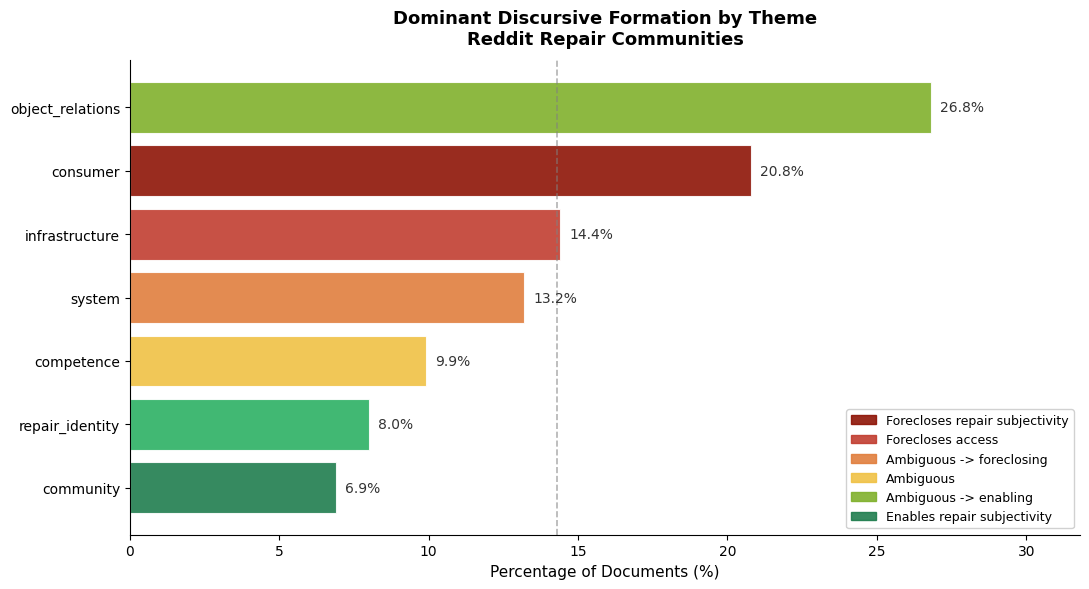

In [323]:
# Dominant theme distribution bar chart

color_map ={
   'consumer': "#8b0e00", 
    'infrastructure': '#c0392b', 
    'competence': '#f0c040', 
    'system': '#e07b39', 
    'object_relations': '#7daf27', 
    'repair_identity': '#27ae60', 
    'community': '#1a7a4a'
}

# distribution of themes mapped by colour_map


plot_data = table1.sort_values('Dominant %', ascending=True)
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    plot_data['Theme'], # y-axis: theme names
    plot_data['Dominant %'], # x-axis: percentages
    color=[colour_map[t] for t in plot_data['Theme']], #colour per theme
    alpha=0.88,
    edgecolor='white',
    linewidth=0.8
)

# Add percentage labels at the end of each bar
for bar, val in zip(bars, plot_data['Dominant %']): 
    ax.text(
        bar.get_width() + 0.3, 
        bar.get_y() + bar.get_height() / 2, 
        f'{val}%', 
        va='center', 
        ha='left',            
        fontsize=10,
        color='#333333'
    )

# adding a line to show which themes are over or under-represented compared to a baseline of equal distribution across themes 
equal_dist = 100 / len(theme_names) # 100 / 7 themes = 14.3% — bars longer than this are over-represented
ax.axvline(
    x=equal_dist,
    color='grey',
    linestyle='--',
    alpha=0.6,
    linewidth=1.2,
    label=f'Equal distribution ({equal_dist:.1f}%)'
)

# legend for theme - colour key 
legend_elements = [
    mpatches.Patch(color="#8b0e00", alpha=0.88, label='Forecloses repair subjectivity'), # consumer
    mpatches.Patch(color='#c0392b', alpha=0.88, label='Forecloses access'), # infrastructure
    mpatches.Patch(color="#e07b39", alpha=0.88, label='Ambiguous -> foreclosing'), # system
    mpatches.Patch(color='#f0c040', alpha=0.88, label='Ambiguous'), # competence
    mpatches.Patch(color="#7daf27", alpha=0.88, label='Ambiguous -> enabling'), # object relations
    mpatches.Patch(color="#1a7a4a", alpha=0.88, label='Enables repair subjectivity') # community
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_xlabel('Percentage of Documents (%)', fontsize=11)
ax.set_title('Dominant Discursive Formation by Theme\nReddit Repair Communities',fontsize=13, fontweight='bold', pad=12)

ax.set_xlim(0, max(plot_data['Dominant %']) + 5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout() 
plt.savefig('vis1_theme_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

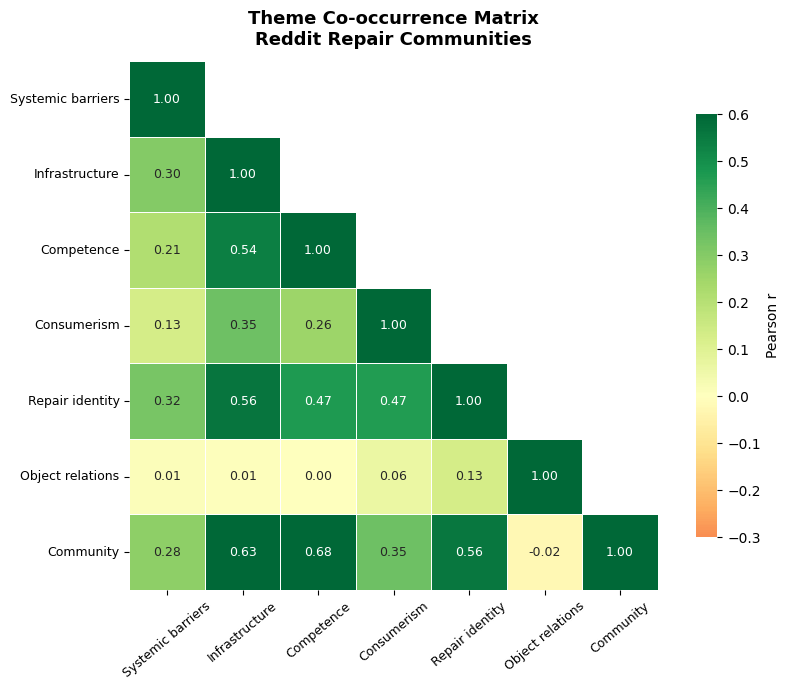

In [292]:
# Co-occurrence heatmap 
# Create dictionary 'labels' for descriptive versions of theme names to use as axis labels in the heatmap
labels = {
    'consumer': 'Consumerism',
    'infrastructure': 'Infrastructure',
    'competence': 'Competence',
    'system': 'Systemic barriers',
    'object_relations': 'Object relations',
    'repair_identity': 'Repair identity',
    'community': 'Community',
}

# constructing the heatmap
corr_display = corr.rename(index=labels, columns=labels)
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1) # creating a mask to hide the upper triangle of the matrix, since it's symmetric 
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_display,
    ax=ax,
    mask=mask,
    cmap='RdYlGn',  # Red = negative correlation, Yellow = zero correlation, Green = positive correlation
    center=0, # yellow = 0 correlation
    vmin=-0.3, vmax=0.6,  # colour scale range
    annot=True, # writing correlation value in each cell
    fmt='.2f', # 2dp
    annot_kws={'size': 9},
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}) # colour bar legend settings


ax.set_title('Theme Co-occurrence Matrix\nReddit Repair Communities', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=40, labelsize=9) # diagnoal axis x labels for readability
ax.tick_params(axis='y', rotation=0,  labelsize=9) 
plt.tight_layout()
plt.savefig('vis2_cooccurrence_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


### Manual Validation of Theme Dictionaries - checking if the documents actually match the assigned themes

In [10]:
# Adding original text to similarity_df 
similarity_df['original_text'] = filtered_repair_df['combined_text'].values 
similarity_df.head()


,system,infrastructure,competence,consumer,repair_identity,object_relations,community,dominant_theme,max_similarity,low_signal,original_text
0,0.016765,0.063012,0.018757,0.066583,0.076226,0.038111,0.076549,community,0.076549,False,What model do you have?\n\nTomTom GPS devices ...
1,0.018914,0.040863,0.019714,0.062640,0.000000,0.047094,0.035510,consumer,0.062640,False,"Meanwhile, my 12 year old little Garmin nuvi 2..."
2,0.090391,0.032309,0.016403,0.088790,0.101834,0.006824,0.062382,repair_identity,0.101834,False,"For the lifetime they determine, not for how l..."
3,0.000000,0.036390,0.052114,0.000000,0.000000,0.039149,0.000000,competence,0.052114,False,Contact your state's attorney general's office...
4,0.000000,0.000000,0.070990,0.000000,0.000000,0.000000,0.000000,competence,0.070990,False,"In Massachusetts, lifetime on a contract means..."


In [ ]:
# Save as csv 
similarity_df.to_csv('tfidf_similarity_results.csv', index=False)

In [11]:
# themes as columns
theme_names = ['system', 'infrastructure', 'competence', 'consumer',
               'repair_identity', 'object_relations', 'community']

# sort by top 10 strongest matches per theme
top_docs_df = pd.DataFrame()
for theme in theme_names:
    top_docs = similarity_df.sort_values(by=theme, ascending=False).head(10)
    top_docs = top_docs[top_docs[theme] >= 0.1] # only include documents with similarity above 0.1 for this theme
    top_docs['matched_theme'] = theme
    top_docs_df = pd.concat([top_docs_df, top_docs], ignore_index=True)
top_docs_df.head()

,system,infrastructure,competence,consumer,repair_identity,object_relations,community,dominant_theme,max_similarity,low_signal,original_text,matched_theme
0,0.258816,0.043740,0.066462,0.024553,0.045837,0.007642,0.025263,system,0.258816,False,Not at all what I'm doing. I'm largely not eve...,system
1,0.257923,0.000000,0.000000,0.033954,0.048659,0.000000,0.000000,system,0.257923,False,if you put pressure on the lock and start roll...,system
2,0.247350,0.018236,0.014633,0.056441,0.064212,0.041972,0.053784,system,0.247350,False,"They are going to have to change eventually, a...",system
3,0.227643,0.000000,0.000000,0.080883,0.035098,0.000000,0.000000,system,0.227643,False,"Well, I meant something more like I have been ...",system
4,0.225074,0.040921,0.031549,0.095497,0.040503,0.031656,0.062691,system,0.225074,False,A lot of people are commenting so I just wante...,system


In [13]:
# opening the Excel file in Excel on Mac
import os

def open_file(path):
    if os.name == 'posix':  # macOS
        os.system(f'open "{path}"')
    else:
        print("Unsupported OS")


In [ ]:
top_docs_df.to_csv('top_documents_per_theme.csv', index=False)
# upload to excel for viewing
top_docs_df.to_excel('top_documents_per_theme.xlsx', index=False)
# open file
open_file('top_documents_per_theme.xlsx')

In [16]:
# sort for low_signal documents
low_signal_docs = similarity_df[similarity_df['low_signal']].copy()
# reduce to 
low_signal_docs.to_csv('low_signal_documents.csv', index=False)
open_file('low_signal_documents.csv')


In [21]:
# upload random sample of low-signal documents to excel for manual review
low_signal_docs.sample(20, random_state=42).to_excel('low_signal_sample.xlsx', index=False)
open_file('low_signal_sample.xlsx')

### Labelled Docs for Vallidation

In [25]:
# upload top_documents_per_theme.xlsx as df to show manual validation 
top_docs_val_df = pd.read_excel('top_documents_per_theme.xlsx')
top_docs_val_df.head()


,system,infrastructure,competence,consumer,repair_identity,object_relations,community,dominant_theme,max_similarity,low_signal,original_text,theme,VALIDITY,REASON,misleading words,Column1
0,0.258816,0.043740,0.066462,0.024553,0.045837,0.007642,0.025263,system,0.258816,False,Not at all what I'm doing. I'm largely not eve...,system,VALID,NaN,NaN,NaN
1,0.257923,0.000000,0.000000,0.033954,0.048659,0.000000,0.000000,system,0.257923,False,if you put pressure on the lock and start roll...,system,INVALID,irrelevant,resistance,NaN
2,0.247350,0.018236,0.014633,0.056441,0.064212,0.041972,0.053784,system,0.247350,False,"They are going to have to change eventually, a...",system,VALID,NaN,NaN,NaN
3,0.227643,0.000000,0.000000,0.080883,0.035098,0.000000,0.000000,system,0.227643,False,"Well, I meant something more like I have been ...",system,VALID,NaN,NaN,NaN
4,0.225074,0.040921,0.031549,0.095497,0.040503,0.031656,0.062691,system,0.225074,False,A lot of people are commenting so I just wante...,system,VALID,NaN,NaN,NaN


In [26]:
# upload low_signal_sample.xlsx as df to show manual validation 
low_signal_val_df = pd.read_excel('low_signal_sample.xlsx')
low_signal_val_df.head()

,system,infrastructure,competence,consumer,repair_identity,object_relations,community,dominant_theme,max_similarity,low_signal,original_text,VALIDITY,REASON,MISSING WORDS
0,0.025387,0.000000,0.000000,0.026415,0.000000,0.000000,0.000000,consumer,0.026415,True,"Fair point, but if some of them work you can w...",VALID,competence,"easy to repair, stop working"
1,0.000000,0.032459,0.022651,0.043061,0.000000,0.015107,0.024529,consumer,0.043061,True,Damn dude.\n\nMy dad and I love bifolds but da...,INVALID,low-signal/ambiguous,NaN
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,system,0.000000,True,i love this!!! i was just thinking the other d...,INVALID,low-signal/ambiguous,NaN
3,0.009980,0.024815,0.013150,0.019032,0.028544,0.000000,0.000000,repair_identity,0.028544,True,Interesting to me too. Seems the advantage her...,VALID,system,design
4,0.000000,0.035621,0.000000,0.029463,0.000000,0.040980,0.000000,object_relations,0.040980,True,There is an inverse relationship between the c...,INVALID,low-signal/irrelevant,NaN


## Collocation Analysis

In [293]:
# Importing libraries
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from collections import defaultdict
import nltk
bigrams = nltk.collocations.BigramAssocMeasures()
bigramFinder = nltk.collocations.BigramCollocationFinder.from_words(all_tokens)

In [294]:
#bigrams
bigram_freq = bigramFinder.ngram_fd.items()
bigramFreqTable = pd.DataFrame(list(bigram_freq), columns=['bigram','freq']).sort_values(by='freq', ascending=False)
bigramFreqTable.head(20)

,bigram,freq
1142,"(not, know)",107
338,"(not, want)",84
1039,"(not, even)",70
287,"(long, time)",66
1474,"(not, go)",65
473,"(year, ago)",63
1871,"(people, not)",57
140,"(make, sure)",57
756,"(not, need)",56
1628,"(not, get)",54


In [295]:
# counting tokens
docs = filtered_repair_df['lemmatised_text'].tolist() # list of lemmatised posts/comments
with open('lemmatised_corpus.txt', 'w', encoding='utf-8') as f:
    for text in filtered_repair_df['lemmatised_text']:
        f.write(text.strip() + '\n') # making plain text file with one document per line 

all_tokens = [] # list to hold all tokens from the corpus
for doc in docs:
    all_tokens.extend(doc.split()) # splitting each document into tokens and adding to the list

print(len(all_tokens)) # total tokens in corpus
print(len(set(all_tokens))) # unique tokens in corpus

97508
9712


In [296]:
# collatation pipeline
def get_collocates(tokens, target_word, window_size=5, top_n=20):
    collocate_counts = defaultdict(int)
    for i, token in enumerate(tokens):
        if token == target_word:
            # defining the context window around the target word
            left = max(0, i - window_size)
            right = min(len(tokens), i + window_size + 1)
            context = tokens[left:i] + tokens[i+1:right]
            for collocate in context:
                collocate_counts[collocate] += 1

    df = pd.DataFrame(collocate_counts.items(), columns=['collocate', 'count']).sort_values('count', ascending=False)
    return df.head()

# 10 target words - chosen based on their relevance to the themes and their frequency in the corpus
target_words = ['repair', 'fix', 'material', 'replace', 'new', 'waste', 'worth', 'throw', 'memory', 'environment']

for word in target_words:
    frequency = all_tokens.count(word) # how many times target word appears in the corpus
    if frequency == 0:
        print(f"'{word}' does not appear in the corpus.")
    else:
        print(f"'{word}' appears {frequency} times in the corpus.")
        collocates_df = get_collocates(all_tokens, word)
        print(f"Top collocates for '{word}':") # most common words that appear in 5-word window
        print(collocates_df.to_string(index=False))

'repair' appears 226 times in the corpus.
Top collocates for 'repair':
collocate  count
      not     71
      use     30
   repair     28
      get     25
     need     22
'fix' appears 238 times in the corpus.
Top collocates for 'fix':
collocate  count
      not     95
      fix     36
      get     29
       go     25
    thing     24
'material' appears 78 times in the corpus.
Top collocates for 'material':
collocate  count
      not     30
      use     14
     cost     14
     make     12
     time     12
'replace' appears 138 times in the corpus.
Top collocates for 'replace':
collocate  count
      not     46
     time     24
     need     19
      get     18
   repair     17
'new' appears 315 times in the corpus.
Top collocates for 'new':
collocate  count
      not     76
      buy     71
      get     54
     time     43
      use     40
'waste' appears 267 times in the corpus.
Top collocates for 'waste':
collocate  count
      not    108
  plastic     45
     make     33
     

In [297]:
# df with keyword, frequency of keyword, top collocations around key word, and frequency of collocates
collocation_results = []
for word in target_words:
    frequency = all_tokens.count(word)
    if frequency > 0:
        collocates_df = get_collocates(all_tokens, word)
        for _, row in collocates_df.iterrows():
            collocation_results.append({
                'keyword': word,
                'keyword_freq': frequency,
                'collocate': row['collocate'],
                'collocate_freq': row['count']
            })
collocation_results_df = pd.DataFrame(collocation_results)
# show 3 rows per distinct keyword
collocation_results_df = collocation_results_df.groupby('keyword').head(5)
collocation_results_df.head()


,keyword,keyword_freq,collocate,collocate_freq
0,repair,226,not,71
1,repair,226,use,30
2,repair,226,repair,28
3,repair,226,get,25
4,repair,226,need,22


### PMI and log-likelihood

In [298]:
# bigram finder with window of 5
finder = BigramCollocationFinder.from_words(all_tokens, window_size=5)
finder.apply_freq_filter(3) # pairs must appear at least 3 times

measures = BigramAssocMeasures() # measures for scoring collocations, including PMI and log-likelihood
pmi_scores = dict(finder.score_ngrams(measures.pmi))
ll_scores  = dict(finder.score_ngrams(measures.likelihood_ratio))
freq_scores = dict(finder.ngram_fd)

# building results table
results = []
for bigram in pmi_scores:
    results.append({
        'word_1': bigram[0],
        'word_2': bigram[1],
        'frequency': freq_scores.get(bigram, 0),
        'pmi': round(pmi_scores[bigram], 3),
        'log_likelihood': round(ll_scores.get(bigram, 0), 3),})

collocations_df = pd.DataFrame(results).sort_values('log_likelihood', ascending=False)

# filtering for collocations involving target words
def get_targeted_stats(df, target_word, top_n=15):
    mask = (df['word_1'] == target_word) | (df['word_2'] == target_word)
    result = df[mask].copy()
    result['collocate'] = result.apply(lambda r: r['word_2'] if r['word_1'] == target_word else r['word_1'],axis=1)
    return result[['collocate', 'frequency', 'pmi', 'log_likelihood']]\
           .sort_values('log_likelihood', ascending=False)\
           .head(top_n)

for word in target_words:
    print(f"\n Collocates of '{word}' (PMI + LL)")
    print(get_targeted_stats(collocations_df, word).to_string(index=False))

collocations_df.to_csv('collocations_full.csv', index=False)
collocations_df.head()


 Collocates of 'repair' (PMI + LL)
 collocate  frequency   pmi  log_likelihood
 appliance         16 5.468          22.975
      shop         11 4.190          10.911
     right         15 3.045           9.344
    repair         14 2.740           7.422
     dryer          6 4.209           5.981
    clinic          3 6.753           5.740
      call          8 2.822           4.428
  diagnose          3 5.338           4.159
      need         15 1.818           4.125
 agreement          3 4.879           3.675
relatively          3 4.638           3.425
      part         10 2.053           3.349
      anti          3 4.531           3.315
       diy          4 3.666           3.268
     video          6 2.723           3.141

 Collocates of 'fix' (PMI + LL)
collocate  frequency   pmi  log_likelihood
     easy         15 3.541          11.692
    issue          9 3.263           6.208
      fix         13 2.484           5.914
  problem          9 3.080           5.693
  problem   

,word_1,word_2,frequency,pmi,log_likelihood
660,tape,measure,43,7.879,99.664
1903,year,ago,65,5.014,84.832
249,cast,iron,17,9.619,49.955
132,moderator,compose,14,10.573,46.091
142,automatically,moderator,14,10.486,45.615


In [299]:
# concordance for repair and fix synonyms 
from nltk.text import Text
corpus_text = Text(all_tokens) 
corpus_text.concordance('repair', width=50, lines=20) 

Displaying 20 of 226 matches:
sell small electronic repair part not profitable e
 need common resistor repair project not want wait
fe entail maintenance repair ok not item last not 
ctually use much need repair frequently order surv
nce hold well grandpa repair unit model long disin
ure look avoid common repair failure personally ha
asy regular servicing repair last forever product 
zy old appliance easy repair component not print s
friend gift wreck car repair use daily driver miss
 life time constantly repair duh brother law ram t
nd slightly check com repair info classic accord h
arily injure able car repair choice good op great 
 however not say ever repair wild car also accord 
 work fine year break repair year later not not ex
ys give inability fly repair signal send form elec
use need buy ebay see repair nickelodeon clock per
ay replace lose break repair not enough not job ye
achine need make good repair assume rip seam fabri
ber perfect look shoe repair place live probably c
u

In [300]:
corpus_text.concordance('fix', width=50, lines=20) 

Displaying 20 of 238 matches:
offer discount without fix actual problem right y
 wifi network get good fix location live city las
insurance investigator fix dent fender total van 
pizza delivery wage do fix shame nice car get hon
ghbor friend start try fix know next thing know g
instrument board probe fix place whole probe orie
le try test issue lens fix webb look promising wa
 no even suggest maybe fix grandfather work rockw
several people suggest fix overrule ebele sound a
 yo mean push actually fix problem safe launch co
t minute day know easy fix type issue brother sta
tom badly scratch know fix buy set kosher reason 
nless steel towel rail fix ceiling attach meat ho
a find new version get fix other make great point
 wear pretty hard even fix partly tape get lot ne
llet take no shame get fix mend part break physic
leather restore polish fix seam issue get back mo
t able continue amount fix not know idea product 
ssional conman promise fix people gullible not ne
 change come along s

## LDA Topic Modelling

In [301]:
import gensim
from gensim import corpora
from gensim.models import LdaModel, LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [302]:
# loading lemmatised corpus from text file
# filtering out high-freuquency stopwords 

custom_stopwords = set(STOPWORDS).union({
    # Reddit speak — automated moderator language
    'submission', 'courteous', 'helpful', 'moderator', 'mod',
    'removed', 'deleted', 'edit', 'update', 'post', 'comment',
    'thread', 'subreddit', 'reddit',
    # high-frequency repair-neutral terms that add noise and carry no thematic information
    'yeah', 'yep', 'nope', 'lol', 'ok', 'okay', 'got', 'get',
    'going', 'went', 'come', 'came', 'said', 'say', 'know',
    'think', 'want', 'need', 'look', 'looking', 'lot', 'bit',
    'pretty', 'actually', 'probably', 'maybe', 'even', 'still',
    'also', 'well', 'back', 'way', 'thing', 'things', 'good',
    'great', 'really', 'just', 'like', 'use', 'used', 'using',
    'make', 'made', 'making', 'time', 'year', 'day', 'week',
})

with open('lemmatised_corpus.txt', 'r', encoding='utf-8') as f:
    documents = [
        [token for token in line.strip().split() # split line into tokens
         if token not in custom_stopwords   # remove stopwords
         and len(token) > 2 # remove very short tokens (including 'a', 'an')
         and token.isalpha()] # remove numbers, punctuation, and mixed tokens
        for line in f # iterate through each line
        if line.strip()  # skip empty lines
    ]

documents = [d for d in documents if len(d) >= 5] # removing very short documents

print(f"Documents after filtering: {len(documents):,}")
print(f"Mean document length: {sum(len(d) for d in documents) / len(documents):.1f} tokens")
print(f"\nSample document:")
print(f"  Tokens: {documents[0][:20]}")

Documents after filtering: 2,774
Mean document length: 25.8 tokens

Sample document:
  Tokens: ['model', 'tomtom', 'gps', 'device', 'shitty', 'lockout', 'extremely', 'easy', 'hack', 'pirate', 'map', 'dad', 'refuse', 'buy', 'new', 'gps', 'tomtom', 'routers', 'edition', 'model']


In [303]:
# making a dictionary from the tokenised docs
dictionary = corpora.Dictionary(documents)
print(f"\nVocabulary before filtering: {len(dictionary):,} unique words")

# checking frequency distribution before applying thresholds
freqs = [dictionary.dfs[id] for id in dictionary.keys()]
print(f"\nWord frequency distribution:")
print(f"  Appearing in >= 2 docs:  {sum(1 for f in freqs if f >= 2):,}")
print(f"  Appearing in >= 5 docs:  {sum(1 for f in freqs if f >= 5):,}")
print(f"  Appearing in >= 10 docs: {sum(1 for f in freqs if f >= 10):,}")
print(f"  Appearing in >= 20 docs: {sum(1 for f in freqs if f >= 20):,}")

# no_below: word must appear in at least this many documents removes rare words that are too specific to single documents and cannot form meaningful cross-document topics
# no_above: word must appear in fewer than this proportion of documents removes words so common they appear in every topic and therefore distinguish nothing between topics
# keep_n: retain only the most frequent words after filtering keeps the vocabulary manageable for computation
dictionary.filter_extremes(no_below=5, no_above=0.7, keep_n=8000)
print(f"Vocabulary after filtering:  {len(dictionary):,} unique words")

# converting each document from a list of word strings nto a list of (word_id, word_count) pairs
bow_corpus = [dictionary.doc2bow(doc) for doc in documents]


Vocabulary before filtering: 9,215 unique words

Word frequency distribution:
  Appearing in >= 2 docs:  4,803
  Appearing in >= 5 docs:  2,334
  Appearing in >= 10 docs: 1,361
  Appearing in >= 20 docs: 692
Vocabulary after filtering:  2,334 unique words


Python(82088) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82090) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82091) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


k= 5  c_v=0.3734  u_mass=-3.5515


Python(82126) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82128) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82129) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


k= 7  c_v=0.3870  u_mass=-3.5646


Python(82275) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82276) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82277) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

k=21  c_v=0.3650  u_mass=-5.3648


Python(82435) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82436) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82437) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


k=23  c_v=0.3503  u_mass=-5.6726


Python(82441) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82442) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82443) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


k=25  c_v=0.3351  u_mass=-6.1202


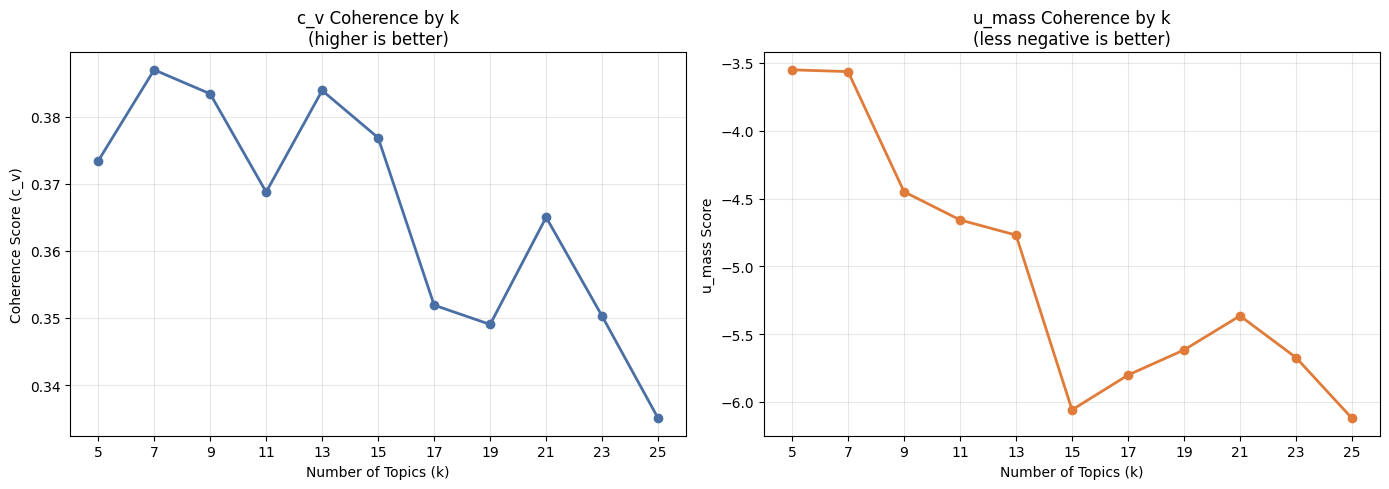


Best k by c_v: 7 (score=0.3870)
Best k by u_mass: 5


In [304]:
# coherence search across k values to find the optimal number of topics for LDA modelling

def compute_coherence_scores(corpus, dictionary, texts, k, passes=15):
    """Train LDA model and return both c_v and u_mass coherence scores."""
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,        
        passes=passes,          
        alpha='auto',           
        eta='auto',             
        per_word_topics=True    
    )

    # c_v coherence — higher is better
    cv = CoherenceModel(
        model=model, texts=texts,
        dictionary=dictionary, coherence='c_v'
    ).get_coherence()

    # u_mass coherence — closer to 0 is better
    umass = CoherenceModel(
        model=model, texts=texts,
        dictionary=dictionary, coherence='u_mass'
    ).get_coherence()

    return model, cv, umass

k_values = list(range(5, 26, 2))  # 5, 7, 9, ..., 25 
cv_scores = []
umass_scores = []
models = {}


for k in k_values:
    model, cv, umass = compute_coherence_scores(bow_corpus, dictionary, documents, k)
    cv_scores.append(cv)
    umass_scores.append(umass)
    models[k] = model
    print(f"k={k:2d}  c_v={cv:.4f}  u_mass={umass:.4f}")

# plot coherence scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, cv_scores, marker='o', linewidth=2, color='#4a6fa5')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('Coherence Score (c_v)')
axes[0].set_title('c_v Coherence by k\n(higher is better)')
axes[0].set_xticks(k_values)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, umass_scores, marker='o', linewidth=2, color='#e07b39')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('u_mass Score')
axes[1].set_title('u_mass Coherence by k\n(less negative is better)')
axes[1].set_xticks(k_values)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coherence_plot_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# find k with best c_v
best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"\nBest k by c_v: {best_k} (score={max(cv_scores):.4f})")
print(f"Best k by u_mass: {k_values[umass_scores.index(max(umass_scores))]}")


In [305]:
# training LDA model with best k and more passes/iterations for better convergence

lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=7,
    random_state=42,
    passes=20, # more passes than search phase for better convergence
    iterations=400, # more iterations within each pass
    alpha='auto', # alpha = document-topic density
    eta='auto',  # eta = topic-word density
    per_word_topics=True, 
    chunksize=500 # number of documents per training chunk 
)

final_coherence = CoherenceModel(
    model=lda_model,
    texts=documents,
    dictionary=dictionary,
    coherence='c_v').get_coherence()

print(f"\nFinal model coherence (c_v): {final_coherence:.4f}")

# top 20 words per document 
print(f"\n Top words per topic:")
for i in range(7):
    topic_string = lda_model.print_topic(i, topn=20)
    words = [w.split('*')[1].strip().strip('"')
             for w in topic_string.split(' + ')]
    print(f"\nTopic {i:2d}: {', '.join(words)}")

Python(82546) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82547) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(82548) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Final model coherence (c_v): 0.3264

 Top words per topic:

Topic  0: work, end, wedding, equipment, project, right, tool, tile, design, glue, different, ask, high, month, watch, large, plan, apply, manufacturer, rent

Topic  1: food, paper, banana, college, bag, metal, packaging, natural, link, yarn, reduce, paint, husband, message, concern, wash, straw, wood, prefer, washer

Topic  2: water, hour, video, car, try, home, bring, run, let, local, require, remove, cost, knob, work, check, dollar, damage, drive, question

Topic  3: work, new, buy, old, eat, love, stuff, little, fix, start, cheap, clean, add, hard, turn, lunch, usually, machine, save, meat

Topic  4: cost, waste, pay, product, long, job, free, company, thank, buy, issue, mean, price, money, small, spend, high, single, save, sub

Topic  5: repair, replace, fix, battery, phone, break, wire, easy, window, device, replacement, dryer, open, number, service, door, model, unit, display, likely

Topic  6: people, live, life, lear

In [306]:
topic_labels = {
    0: 'Material project planning — DIY repair and making within institutional constraint',
    1: 'Zero waste lifestyle discourse — material consumption and sustainable living',
    2: 'Practical repair problem-solving — diagnosis and cost calculation at breakdown',
    3: 'Frugal domestic life — thrift, maintenance, and everyday consumption economics',
    4: 'Economic critique of consumer product systems — cost, value, corporate responsibility',
    5: 'Consumer electronics repair — technical diagnosis and repair-replace decision',
    6: 'Domestic values and intergenerational material ethics — family and sustainable practice',
}

theme_mapping = {
    0: 'infrastructure_precarity + repair_as_self_making', # DIY repair as material project within institutional constraint
    1: 'consuming_subject_as_default', # counter-formation — conscious departure from default subjectivity
    2: 'competence + infrastructure',  # threshold between both
    3: 'consuming_subject_as_default + object_relations',  # economically constrained form
    4: 'system_designed_against_repair + consuming_subject',  # consumerism as system design strategy 
    5: 'competence + system_designed_against_repair', # technically oriented and system critic form
    6: 'community_as_world_making + competence',  # domestic/intergenerational form
}

subject_position_mapping = {
    0: 'Self-directed maker navigating material and institutional barriers',
    1: 'Conscious material consumer — lifestyle curation as departure from consumer default',
    2: 'Threshold repair subject — practically oriented, economically aware, identity-neutral',
    3: 'Frugal domestic subject — maintenance motivated by economic necessity not repair identity',
    4: 'Economically frustrated systemic critic — corporate frustration not ideological opposition',
    5: 'Technically oriented repair subject navigating repair-replace decision for devices',
    6: 'Domestically situated values subject — material responsibility enacted within family',
}

In [307]:
# checking topic overlap to ensure semantic distinction - Jensen-Shannon divergence between all topic pairs
# low divergence = high overlap = topics are too similar
from scipy.spatial.distance import jensenshannon

print("\n Topic overlap check (Jensen-Shannon divergence)")
print("Higher = more distinct. Lower = more overlap.")

# get topic-word distributions for all topics
topic_word_matrix = lda_model.get_topics()   # shape: (k, vocab_size)

overlap_scores = []
for i in range(7):
    for j in range(i+1, 7):
        js = jensenshannon(topic_word_matrix[i], topic_word_matrix[j])
        overlap_scores.append((i, j, js))
        if js < 0.3:
            print(f"  Topics {i} and {j}: JS={js:.3f} — HIGH OVERLAP")

if not any(s < 0.3 for _, _, s in overlap_scores):
    print("No highly overlapping topic pairs")

mean_js = np.mean([s for _, _, s in overlap_scores])
print(f"\nMean JS divergence across all pairs: {mean_js:.3f}")

# checking topic dominance to ensure no single topic is overwhelming the corpus
assignments = []
for bow_doc in bow_corpus:
    topic_dist = lda_model.get_document_topics(bow_doc, minimum_probability=0)
    dominant = max(topic_dist, key=lambda x: x[1])
    assignments.append(dominant[0])

assignments_series = pd.Series(assignments)
prevalence = (assignments_series.value_counts(normalize=True) * 100).round(1)

print("\n Topic prevalence (% of corpus)")
for topic_id, pct in prevalence.sort_values(ascending=False).items():
    label = topic_labels.get(topic_id, f'Topic {topic_id}')
    print(f"  Topic {topic_id:2d} ({label}): {pct:.1f}%{flag}")


 Topic overlap check (Jensen-Shannon divergence)
Higher = more distinct. Lower = more overlap.
No highly overlapping topic pairs

Mean JS divergence across all pairs: 0.757

 Topic prevalence (% of corpus)
  Topic  3 (Frugal domestic life — thrift, maintenance, and everyday consumption economics): 36.1%
  Topic  6 (Domestic values and intergenerational material ethics — family and sustainable practice): 25.3%
  Topic  4 (Economic critique of consumer product systems — cost, value, corporate responsibility): 15.1%
  Topic  5 (Consumer electronics repair — technical diagnosis and repair-replace decision): 11.4%
  Topic  0 (Material project planning — DIY repair and making within institutional constraint): 5.4%
  Topic  2 (Practical repair problem-solving — diagnosis and cost calculation at breakdown): 4.9%
  Topic  1 (Zero waste lifestyle discourse — material consumption and sustainable living): 1.9%


In [308]:
# 5 documents most strongly associated with each topic — the most representative documents for each discursive formation
cleaned_corpus = filtered_repair_df['combined_text'].tolist() # list of cleaned text documents
cleaned_corpus = '\n\n'.join(cleaned_corpus) # separate documents by double newline for readability
with open('cleaned_corpus.txt', 'w', encoding='utf-8') as f:
    f.write(cleaned_corpus)

with open('cleaned_corpus.txt', 'r', encoding='utf-8') as f:
    readable_docs = [d.strip() for d in f.read().split('\n\n') if d.strip()]

# building full assignment dataframe with topic probabilities
rows = []
for i, bow_doc in enumerate(bow_corpus):
    topic_dist = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))
    row = {'doc_index': i, 'dominant_topic': assignments[i]}
    for t in range(7):
        row[f'topic_{t}'] = round(topic_dist.get(t, 0), 4)
    rows.append(row)

assignments_df = pd.DataFrame(rows)

# attaching readable text — align on position
if len(readable_docs) >= len(assignments_df):
    assignments_df['text'] = [readable_docs[i]
                              for i in range(len(assignments_df))]
else:
    print("readable_docs length does not match corpus length")
    print(f"readable_docs: {len(readable_docs)}, assignments_df: {len(assignments_df)}")

print("\n Representative documents per topic")
for topic_id in range(7):
    col = f'topic_{topic_id}'
    if col not in assignments_df.columns:
        continue
    top_docs = assignments_df.nlargest(3, col)
    print(f"\nTopic {topic_id}: {topic_labels.get(topic_id, 'unlabelled')}")
    for _, row in top_docs.iterrows():
        print(f"  Score: {row[col]:.3f}")
        if 'text' in assignments_df.columns:
            print(f"  Text:  {row['text'][:250]}")
        print()


 Representative documents per topic

Topic 0: Material project planning — DIY repair and making within institutional constraint
  Score: 0.555
  Text:  Contact your state's attorney general's office.  Legally they may not be able to redefine "lifetime.". Remember Subway saying "footlong" was a marketing term and didn't imply the length of the sandwich?  They got slapped down pretty hard for that.

  Score: 0.537
  Text:  Fuck, if you're gonna provide two years of updates, *then just say that.* Seems to me that the only reason not to say it clearly is *to* be misleading.

  Score: 0.534
  Text:  I've been in two collisions since getting my dashcam in 2016. Both times the footage wasn't necessary (one guy accepted blame, other guy didn't show up to court), but having the footage made me a whole lot less anxious.


Topic 1: Zero waste lifestyle discourse — material consumption and sustainable living
  Score: 0.551
  Text:  It's good in theory, but the average person has no idea real qual

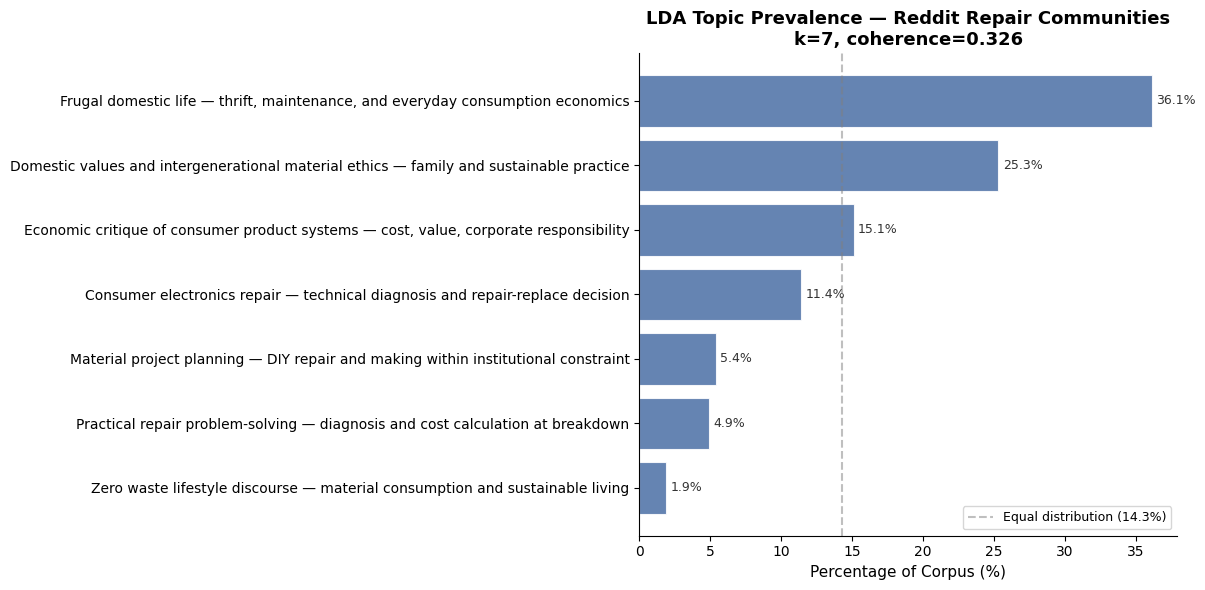

In [309]:
# topic prevelance bar chart 
fig, ax = plt.subplots(figsize=(12, 6))

# sort by prevalence descending
sorted_prevalence = prevalence.sort_values(ascending=True)
labels_plot = [topic_labels.get(t, f'Topic {t}')
               for t in sorted_prevalence.index]

ax.barh(labels_plot, sorted_prevalence.values,
        color='#4a6fa5', alpha=0.85, edgecolor='white', linewidth=0.8)

# equal distribution line — if all topics were equal
ax.axvline(x=100/7, color='grey', linestyle='--',
           alpha=0.5, label=f'Equal distribution ({100/7:.1f}%)')

# add value labels
for i, (label, val) in enumerate(zip(labels_plot, sorted_prevalence.values)):
    ax.text(val + 0.3, i, f'{val:.1f}%',
            va='center', ha='left', fontsize=9, color='#333333')

ax.set_xlabel('Percentage of Corpus (%)', fontsize=11)
ax.set_title(f'LDA Topic Prevalence — Reddit Repair Communities\n'
             f'k={7}, coherence={final_coherence:.3f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lda_topic_prevalence.png', dpi=200, bbox_inches='tight')
plt.show()


In [310]:
# saving all outputs
assignments_df.to_csv('lda_topic_assignments.csv', index=False)
lda_model.save('lda_model_v2')
dictionary.save('lda_dictionary_v2')

# topic summary
topic_summary = pd.DataFrame({
    'topic_id':        list(range(7)),
    'label':           [topic_labels.get(i, 'unlabelled') for i in range(7)],
    'prevalence_pct':  [prevalence.get(i, 0) for i in range(7)],
    'top_words':       [', '.join([
                            w.split('*')[1].strip().strip('"')
                            for w in lda_model.print_topic(i, topn=10).split(' + ')
                        ]) for i in range(7)],
    'theme_mapping':   [theme_mapping.get(i, 'unmapped') for i in range(7)],
    'subject_position':[subject_position_mapping.get(i, 'unmapped')
                        for i in range(7)],
})

topic_summary.to_csv('lda_topic_summary.csv', index=False)
topic_summary.to_excel('lda_topic_summary.xlsx', index=False)

print("\n Saved:")
print("lda_topic_assignments.csv — dominant topic per document")
print("lda_topic_summary.csv/.xlsx — topic labels and top words")
print("lda_model_v2 — trained model")
print("lda_dictionary_v2 — vocabulary")
print("lda_topic_prevalence.png — bar chart")


 Saved:
lda_topic_assignments.csv — dominant topic per document
lda_topic_summary.csv/.xlsx — topic labels and top words
lda_model_v2 — trained model
lda_dictionary_v2 — vocabulary
lda_topic_prevalence.png — bar chart


# Metaphor Prevalence

In [311]:
# randmly selecting 200 posts
df = pd.read_csv('cleaned_corpus.csv')
df_sample = df.sample(n=200, random_state=42)
df_sample = df_sample.reset_index(drop=True)
df_sample.to_csv('sample_200_posts.csv', index=False)

df_sample.head()

,Type,Title,Time Stamp,Score,Id,Url,Num Comments,Post Text,Post Id,Comment Id,Comment Text,combined_text,concordance_text,lemmatised_text
0,comment,NaN,1.706385e+09,1,NaN,NaN,NaN,NaN,jafvl1,kjuj7j3,Why would they turn it on on the first pairing...,Why would they turn it on on the first pairing...,why would they turn it on on the first pairing...,turn pairing let use device show feature liter...
1,comment,NaN,1.743182e+09,2,NaN,NaN,NaN,NaN,1jlk07g,mk7qruk,Is there a Dyson service center near you? I to...,Is there a Dyson service center near you? I to...,is there a dyson service center near you i too...,dyson service center take warranty v15 past we...
2,comment,NaN,1.743188e+09,2,NaN,NaN,NaN,NaN,1jlk07g,mk8cxjz,A bunch of us are have been waiting a year or ...,A bunch of us are have been waiting a year or ...,a bunch of us are have been waiting a year or ...,bunch wait year roller brush replacement part ...
3,comment,NaN,1.681899e+09,1,NaN,NaN,NaN,NaN,nc9090,jgv1u9f,Thanks alot! For now slapping does the trick f...,Thanks alot! For now slapping does the trick f...,thanks alot for now slapping does the trick fo...,thank alot slap trick permafix schlap not work...
4,comment,NaN,1.630308e+09,2,NaN,NaN,NaN,NaN,nc9090,hawhp5g,Having a small piece of fabric seems that be a...,Having a small piece of fabric seems that be a...,having a small piece of fabric seems that be a...,small piece fabric seem permanent fix no issue...


In [246]:
# exporting to Excel for easy scrolling and annotation
df_sample[['combined_text']].to_excel('metaphor_sample.xlsx', index=True)

In [250]:
# opening the Excel file in Excel on Mac
import os

def open_file(path):
    if os.name == 'posix':  # macOS
        os.system(f'open "{path}"')
    else:
        print("Unsupported OS")

open_file('metaphor_sample.xlsx')

In [ ]:
metaphor_sample_df = pd.read_excel('metaphor_sample.xlsx')
metaphor_sample_df = metaphor_sample_df.dropna(subset=['frame_number']) # drop rows with NaN in metaphor column 
metaphor_sample_df.head()

,doc_id,combined_text_doc,subject_position_implied,metaphor,frame_number,primary_framing,secondary_frame_number,secondary_framing
18,18,The hoses for those are a pain in the ass we h...,frustrated repairer,repairing household items is a NIGHTMARE,4.0,breakdown as catastrophe,NaN,NaN
19,19,I'm in the US and unfortunately the service he...,frustrated repairer,repair services as a DISASTER,4.0,breakdown as catastrophe,4.0,product design as GARBAGE
21,21,Same here! Argued with them that there was a g...,frustrated repairer,repair services as RUBBISH,3.0,breakdown as catastrophe,NaN,NaN
31,31,"They have made all the money they need, now th...",consumer subject,design and production as BAIT - ENSHITTIFICATI...,3.0,manufacturers as predators,NaN,NaN
34,34,u/theOmegalord Thank you so much for putting t...,motivated self-directed repairer,communal repairers as LEGENDS,2.0,repairers as legends,NaN,NaN


In [312]:
# loading excel file with metaphor annotations
metaphors = pd.read_excel('metaphor_sample.xlsx')
metaphors = pd.DataFrame(metaphors) # convert to df

frame_map = {
    1: 'repair_as_resurrection',
    2: 'repairers_as_exceptional',
    3: 'manufacturers_as_criminal',
    4: 'breakdown_as_catastrophe',
    5: 'resources_as_mortal',
}

metaphors['primary_frame'] = metaphors['frame_number'].map(frame_map)

# Create boolean indicator columns for each frame label
for frame_label in frame_map.values():
    metaphors[frame_label] = metaphors['primary_frame'] == frame_label 

primary_frame_counts = metaphors['primary_frame'].value_counts()
print(primary_frame_counts)

secondary_frame_counts = metaphors['secondary_frame_number'].map(frame_map).value_counts()
print(secondary_frame_counts)

metaphors['no_metaphor'] = metaphors['frame_number'].isna()
print("\nNo metaphor count:")
print(metaphors['no_metaphor'].value_counts())

primary_frame
repairers_as_exceptional     12
repair_as_resurrection        9
breakdown_as_catastrophe      8
manufacturers_as_criminal     7
resources_as_mortal           7
Name: count, dtype: int64
secondary_frame_number
breakdown_as_catastrophe    5
resources_as_mortal         5
repair_as_resurrection      5
repairers_as_exceptional    3
Name: count, dtype: int64

No metaphor count:
no_metaphor
True     157
False     43
Name: count, dtype: int64


In [266]:
metaphors.head()

,doc_id,combined_text_doc,subject_position_implied,metaphor,frame_number,primary_framing,secondary_frame_number,secondary_framing,primary_frame,repair_as_resurrection,repairers_as_exceptional,manufacturers_as_criminal,breakdown_as_catastrophe,resources_as_mortal,no_metaphor
0,0,Why would they turn it on on the first pairing...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,1,Is there a Dyson service center near you? I to...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True
2,2,A bunch of us are have been waiting a year or ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True
3,3,Thanks alot! For now slapping does the trick f...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True
4,4,Having a small piece of fabric seems that be a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,True


In [313]:
# summary statistics
n_total = len(metaphors)         
n_metaphor = (~metaphors['no_metaphor']).sum()
n_none = metaphors['no_metaphor'].sum()

print(f"Documents with metaphor: {n_metaphor} ({n_metaphor/n_total*100:.1f}%)")
print(f"Documents without metaphor: {n_none} ({n_none/n_total*100:.1f}%)")


print(f"\nFrame prevalence (% of full sample, n={n_total})")

frame_order = ['repair_as_resurrection', 'repairers_as_exceptional',
               'manufacturers_as_criminal', 'breakdown_as_catastrophe',
               'resources_as_mortal']

metaphors['primary_frame'] = metaphors['frame_number'].map(frame_map)

for frame in frame_order:
    metaphors[frame] = metaphors['primary_frame'] == frame
    count = metaphors[frame].sum()
    pct   = count / n_total * 100

summary = pd.DataFrame(
    [(f, metaphors[f].sum(), metaphors[f].mean()*100) for f in frame_order],
    columns=['frame','count','pct']
)
print(summary)

Documents with metaphor: 43 (21.5%)
Documents without metaphor: 157 (78.5%)

Frame prevalence (% of full sample, n=200)
                       frame  count  pct
0     repair_as_resurrection      9  4.5
1   repairers_as_exceptional     12  6.0
2  manufacturers_as_criminal      7  3.5
3   breakdown_as_catastrophe      8  4.0
4        resources_as_mortal      7  3.5


In [314]:
frame_display = {
    'repair_as_resurrection': 'Frame 1 — Repair as salvation',
    'repairers_as_exceptional': 'Frame 2 — Repairers as exceptional beings',
    'manufacturers_as_criminal': 'Frame 3 — Manufacturers as criminals',
    'breakdown_as_catastrophe': 'Frame 4 — Breakdown as catastrophe',
    'resources_as_mortal': 'Frame 5 — Resources as mortal',
}

prevalence = {}
for frame in frame_order:
    count = metaphors[frame].sum()
    pct   = count / n_total * 100
    prevalence[frame] = pct
    print(f"  {frame_display[frame]}: {count} docs ({pct:.1f}%)")

  Frame 1 — Repair as salvation: 9 docs (4.5%)
  Frame 2 — Repairers as exceptional beings: 12 docs (6.0%)
  Frame 3 — Manufacturers as criminals: 7 docs (3.5%)
  Frame 4 — Breakdown as catastrophe: 8 docs (4.0%)
  Frame 5 — Resources as mortal: 7 docs (3.5%)


In [315]:
# framing label breakdown
print(f"\n Specific framing instances:")
framing_counts = metaphors['primary_framing'].value_counts().dropna() # count of each specific framing label, excluding NaN
for label, count in framing_counts.items():
    pct = count / n_total * 100 # 
    print(f"  {label}: {count} ({pct:.1f}%)")


 Specific framing instances:
  breakdown as catastrophe: 6 (3.0%)
  repair is salvation: 6 (3.0%)
  repairers as legends: 5 (2.5%)
  repairers as heros: 3 (1.5%)
  replacement expenditure salvaged: 3 (1.5%)
  time as WASTE: 2 (1.0%)
  repair as resurrection: 2 (1.0%)
  manufacturers as predators: 1 (0.5%)
  product longevity as divine: 1 (0.5%)
  repairers as royalty: 1 (0.5%)
  breakdown as suffering: 1 (0.5%)
  repair as pedagogy: 1 (0.5%)
  manufacturers as thieves: 1 (0.5%)
  manufacturers as crooks: 1 (0.5%)
  repair as rare knowledge: 1 (0.5%)
  repair-return as FRAUD: 1 (0.5%)
  repairers as exceptional: 1 (0.5%)
  resources as mortal: 1 (0.5%)
  manufacturers as criminals: 1 (0.5%)
  repair services as performative: 1 (0.5%)
  object death as unstoppable: 1 (0.5%)
  product design as junk: 1 (0.5%)
  communal aid as GOLD: 1 (0.5%)


In [316]:
# print specific framing instances next to their frame number
print(f"\n Specific framing instances with frame numbers:")
for frame in frame_order:
    frame_name = frame_display[frame]
    specific_labels = metaphors.loc[metaphors[frame], 'primary_framing'].dropna().unique()
    print(f"  {frame_name} ({frame}):")
    for label in specific_labels:
        count = metaphors.loc[metaphors['primary_framing'] == label].shape[0]
        pct = count / n_total * 100
        print(f"    {label}: {count} ({pct:.1f}%)")


 Specific framing instances with frame numbers:
  Frame 1 — Repair as salvation (repair_as_resurrection):
    repair is salvation: 6 (3.0%)
    repair as resurrection: 2 (1.0%)
    object death as unstoppable: 1 (0.5%)
  Frame 2 — Repairers as exceptional beings (repairers_as_exceptional):
    repairers as legends: 5 (2.5%)
    product longevity as divine: 1 (0.5%)
    repairers as royalty: 1 (0.5%)
    repairers as heros: 3 (1.5%)
    repair as rare knowledge: 1 (0.5%)
    repairers as exceptional: 1 (0.5%)
  Frame 3 — Manufacturers as criminals (manufacturers_as_criminal):
    breakdown as catastrophe: 6 (3.0%)
    manufacturers as predators: 1 (0.5%)
    manufacturers as thieves: 1 (0.5%)
    manufacturers as crooks: 1 (0.5%)
    repair-return as FRAUD: 1 (0.5%)
    manufacturers as criminals: 1 (0.5%)
    repair services as performative: 1 (0.5%)
  Frame 4 — Breakdown as catastrophe (breakdown_as_catastrophe):
    breakdown as catastrophe: 6 (3.0%)
    breakdown as suffering: 1 (0

In [317]:
# printing frame numbers with subject positions
print(f"\n Frame numbers with subject positions:")
for frame in frame_order:
    frame_name = frame_display[frame]
    subject_positions = metaphors.loc[metaphors[frame], 'subject_position_implied'].dropna().unique()
    print(f"  {frame_name} ({frame}):")
    for sp in subject_positions:
        count = metaphors.loc[(metaphors[frame]) & (metaphors['subject_position_implied'] == sp)].shape[0]
        pct = count / n_total * 100
        print(f"    {sp}: {count} ({pct:.1f}%)")


 Frame numbers with subject positions:
  Frame 1 — Repair as salvation (repair_as_resurrection):
    motivated self-directed repairer: 6 (3.0%)
    communal advocate: 2 (1.0%)
    refrained repairer: 1 (0.5%)
  Frame 2 — Repairers as exceptional beings (repairers_as_exceptional):
    motivated self-directed repairer: 11 (5.5%)
    consumer subject: 1 (0.5%)
  Frame 3 — Manufacturers as criminals (manufacturers_as_criminal):
    frustrated repairer: 4 (2.0%)
    consumer subject: 1 (0.5%)
    structural critic: 2 (1.0%)
  Frame 4 — Breakdown as catastrophe (breakdown_as_catastrophe):
    frustrated repairer: 6 (3.0%)
    motivated self-directed repairer: 1 (0.5%)
    structural critic: 1 (0.5%)
  Frame 5 — Resources as mortal (resources_as_mortal):
    fatalist repairer: 1 (0.5%)
    motivated self-directed repairer: 2 (1.0%)
    frustrated repairer: 1 (0.5%)
    renounced repairer: 1 (0.5%)
    corporate defender: 1 (0.5%)
    consumer subject: 1 (0.5%)


In [318]:
# which frames appear with which subject positions?
print(f"\n Frame × subject position")
crosstab = pd.crosstab(
    metaphors['subject_position_implied'].fillna('none'),
    metaphors['frame_number'].map(frame_map).fillna('none')
)
print(crosstab.to_string())


 Frame × subject position
frame_number                      breakdown_as_catastrophe  manufacturers_as_criminal  none  repair_as_resurrection  repairers_as_exceptional  resources_as_mortal
subject_position_implied                                                                                                                                          
communal advocate                                        0                          0     0                       2                         0                    0
consumer subject                                         0                          1     0                       0                         1                    1
corporate defender                                       0                          0     0                       0                         0                    1
fatalist repairer                                        0                          0     0                       0                         0                 

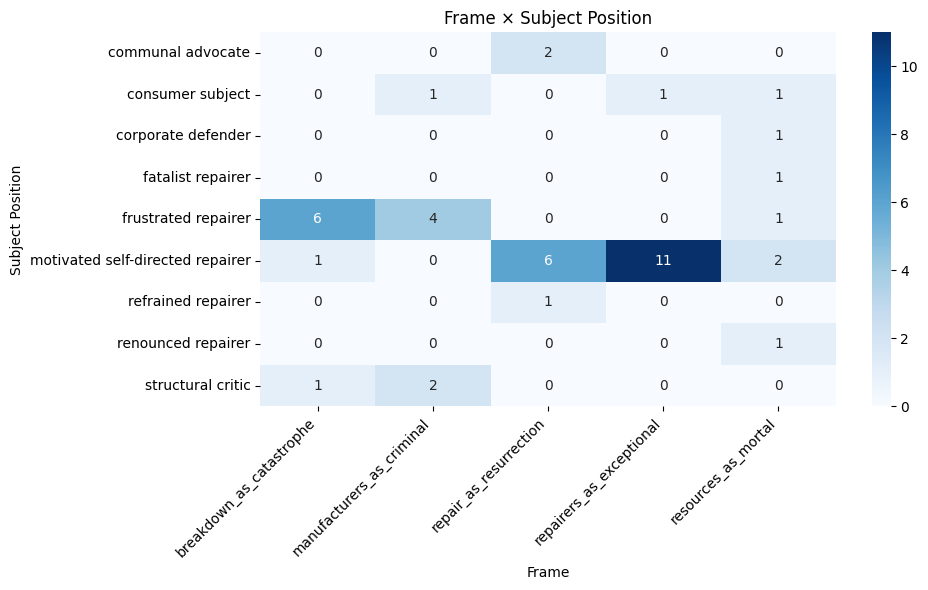

In [319]:
# Frame × subject position as heatmap
crosstab = crosstab.drop('none', errors='ignore').drop('none', axis=1, errors='ignore') 
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Frame × Subject Position')
plt.xlabel('Frame')
plt.ylabel('Subject Position')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('frame_subject_position_heatmap.png', dpi=150)
plt.show()

In [ ]:
# summary table 
summary = pd.DataFrame({
    'frame': [frame_display[f] for f in frame_order],
    'count': [metaphors[f].sum() for f in frame_order],
    'pct_sample': [round(prevalence[f], 1) for f in frame_order],
    'orientation': ['Enables', 'Ambiguous', 'Forecloses', 'Forecloses', 'Ambiguous'],
})
summary.to_csv('metaphor_frame_summary.csv', index=False)
print("\nSaved: metaphor_frame_summary.csv")


Saved: metaphor_frame_summary.csv


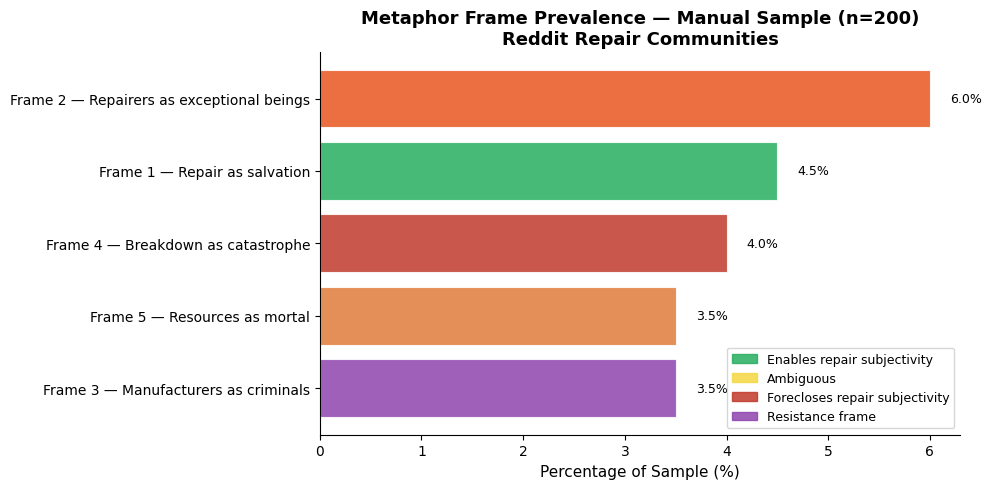


 Key Stats:
Most prevalent frame: Frame 2 — Repairers as exceptional beings (6.0%)
Metaphor present in 21.5% of sample
Most common specific instance: breakdown as catastrophe (6 docs)


In [321]:
# visualisation of metaphor frame prevalence with colour coding for orientation
frame_colours = {
    'repair_as_resurrection': '#27ae60',   # green — enables
    'repairers_as_exceptional':  "#e85620",   # yellow — ambiguous
    'repairers_as_commendable': '#f0c040',   # yellow — ambiguous
    'manufacturers_as_criminal': '#8e44ad',   # purple — resistance
    'breakdown_as_catastrophe':  '#c0392b',   # red — forecloses
    'resources_as_mortal':       '#e07b39',   # orange — ambiguous
}

fig, ax = plt.subplots(figsize=(10, 5))

# Sort by prevalence for readability
sorted_frames = sorted(frame_order, key=lambda f: prevalence[f])
sorted_labels = [frame_display[f] for f in sorted_frames]
sorted_values = [prevalence[f] for f in sorted_frames]
sorted_colours = [frame_colours[f] for f in sorted_frames]

bars = ax.barh(
    sorted_labels, sorted_values,
    color=sorted_colours, alpha=0.85,
    edgecolor='white', linewidth=0.8
)

for bar, val in zip(bars, sorted_values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9)

legend_elements = [
    mpatches.Patch(color='#27ae60', alpha=0.85, label='Enables repair subjectivity'),
    mpatches.Patch(color="#f5d743", alpha=0.85, label='Ambiguous'),
    mpatches.Patch(color='#c0392b', alpha=0.85, label='Forecloses repair subjectivity'),
    mpatches.Patch(color='#8e44ad', alpha=0.85, label='Resistance frame'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Percentage of Sample (%)', fontsize=11)
ax.set_title(
    f'Metaphor Frame Prevalence — Manual Sample (n={n_total})\n'
    f'Reddit Repair Communities',
    fontsize=13, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metaphor_prevalence.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n Key Stats:")
most_prevalent = max(prevalence, key=prevalence.get)
print(f"Most prevalent frame: {frame_display[most_prevalent]} "
      f"({prevalence[most_prevalent]:.1f}%)")
print(f"Metaphor present in {n_metaphor/n_total*100:.1f}% of sample")
print(f"Most common specific instance: "
      f"{framing_counts.index[0]} ({framing_counts.iloc[0]} docs)")